<a href="https://colab.research.google.com/github/SubhadeepAtta/Astrix/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install opendatasets

In [2]:
import opendatasets as od
#KGAT_ca8f350dd0e4f5a33bf0f288e3d8f431

In [3]:
# od.download("https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques")


In [4]:
import pandas as pd
import numpy as np


In [5]:
df=pd.read_csv("/content/sample_data/california_housing_test.csv")

In [6]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


In [7]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='median_income'>

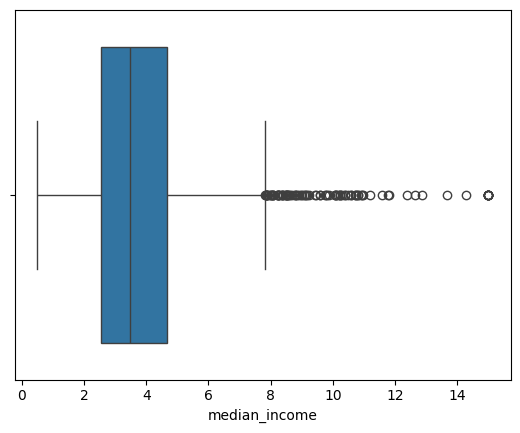

In [9]:
sns.boxplot(x=df['median_income'])

<Axes: xlabel='median_house_value'>

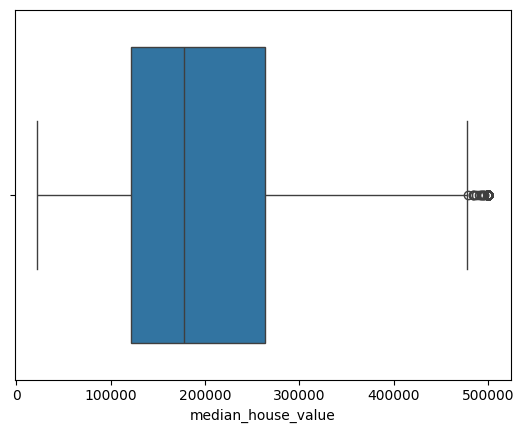

In [10]:
sns.boxplot(x=df['median_house_value'])

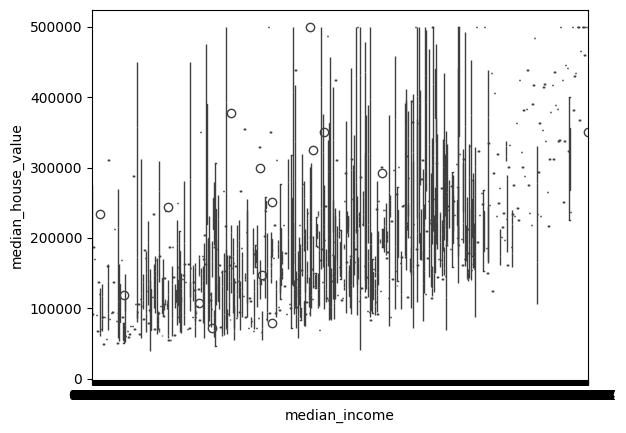

In [11]:
sns.boxplot(x='median_income',y='median_house_value', data=df)
plt.show()

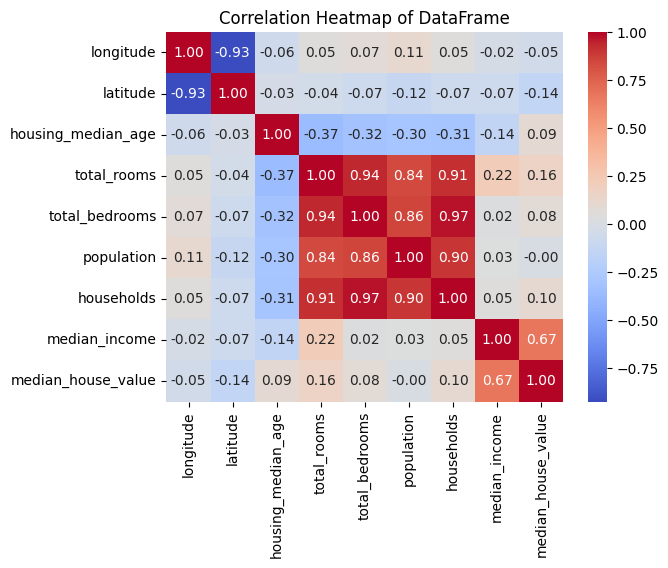

In [12]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of DataFrame')
plt.show()

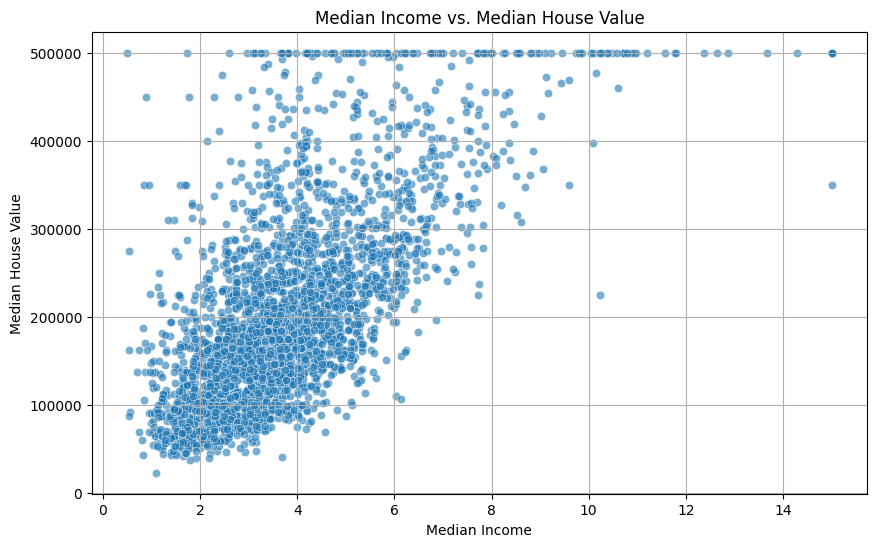

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.6)
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

In [14]:
q1 = df['median_income'].quantile(0.25)
q3= df['median_income'].quantile(0.75)
min_value = q1 - 1.5 * (q3 - q1)
max_value = q3 + 1.5 * (q3 - q1)
df = df[(df['median_income'] >= min_value) & (df['median_income'] <= max_value)]


In [15]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2994,-117.93,33.86,35.0,931.0,181.0,516.0,174.0,5.5867,182500.0
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0


In [16]:
q1 = df['median_house_value'].quantile(0.25)
q3= df['median_house_value'].quantile(0.75)
min_value = q1 - 1.5 * (q3 - q1)
max_value = q3 + 1.5 * (q3 - q1)
df = df[(df['median_house_value'] >= min_value) & (df['median_house_value'] <= max_value)]

In [17]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2994,-117.93,33.86,35.0,931.0,181.0,516.0,174.0,5.5867,182500.0
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0


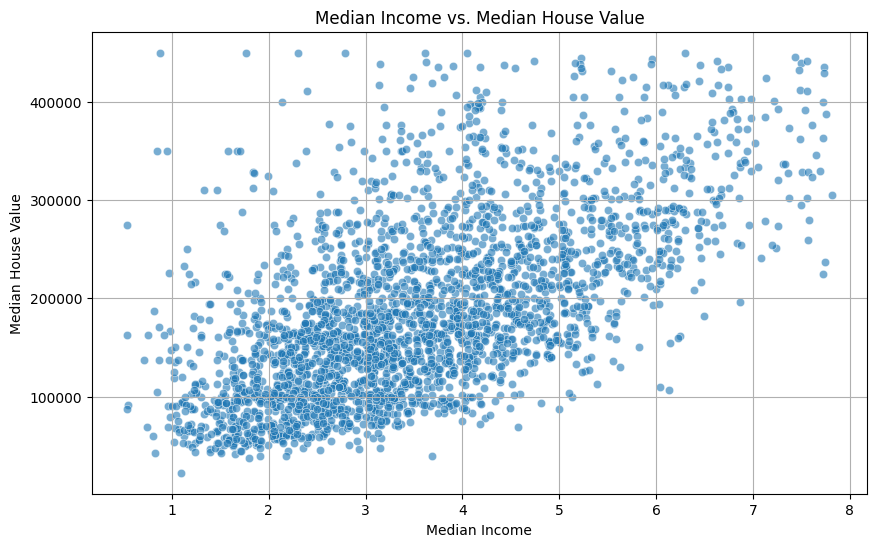

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.6)
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
model=LinearRegression()

In [21]:
input=df[['median_income']]
output=df[['median_house_value']]

In [22]:
model.fit(input,output)

LinearRegression()

In [23]:
predict=model.predict(input)

In [24]:
import numpy as np

In [25]:
def rmse(targets,prediction):
    return np.sqrt(np.mean(np.square(targets-prediction)))

In [26]:
rmse(output,predict)

np.float64(71056.9185737605)

In [27]:
from sklearn.metrics import r2_score
r2 = r2_score(output, predict)
print(f'R-squared score: {r2*100} %')

R-squared score: 37.66754421021752 %


In [28]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,2805.000000,2805.000000,2805.000000,2805.000000,2805.000000,2805.000000,2805.000000,2805.000000,2805.000000
mean,-119.581401,35.661554,28.679857,2557.279144,528.999643,1414.790374,488.927986,3.552504,187080.855615
std,1.995801,2.148002,12.509177,2121.274247,408.352606,1035.628431,357.622745,1.423710,90017.444462
min,-124.180000,32.560000,1.000000,6.000000,2.000000,5.000000,2.000000,0.536000,22500.000000
25%,-121.790000,33.930000,18.000000,1380.000000,291.000000,788.000000,274.000000,2.500000,115900.000000
50%,-118.500000,34.300000,29.000000,2084.000000,437.000000,1176.000000,411.000000,3.369300,170900.000000
75%,-118.020000,37.710000,37.000000,3098.000000,636.000000,1754.000000,598.000000,4.430600,241700.000000
max,-114.490000,41.920000,52.000000,30450.000000,5033.000000,11935.000000,4855.000000,7.813900,450000.000000


In [29]:
def estimated_price(income,w,b):
  return w*income+b

In [30]:
def try_parameters(w,b):
  estimated_prices=estimated_price(input,w,b)
  plt.figure(figsize=(10, 6))
  sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.6)
  plt.title('Median Income vs. Median House Value')
  plt.xlabel('Median Income')
  plt.ylabel('Median House Value')
  plt.plot(input, estimated_prices, color='red', label='Estimated Price')
  plt.legend()
  plt.grid(True)
  plt.show()

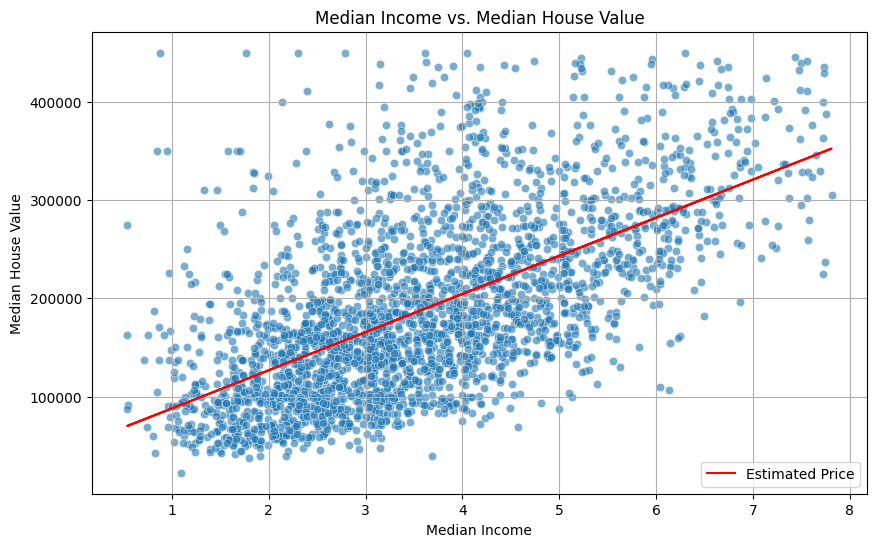

In [31]:
try_parameters(model.coef_,model.intercept_)

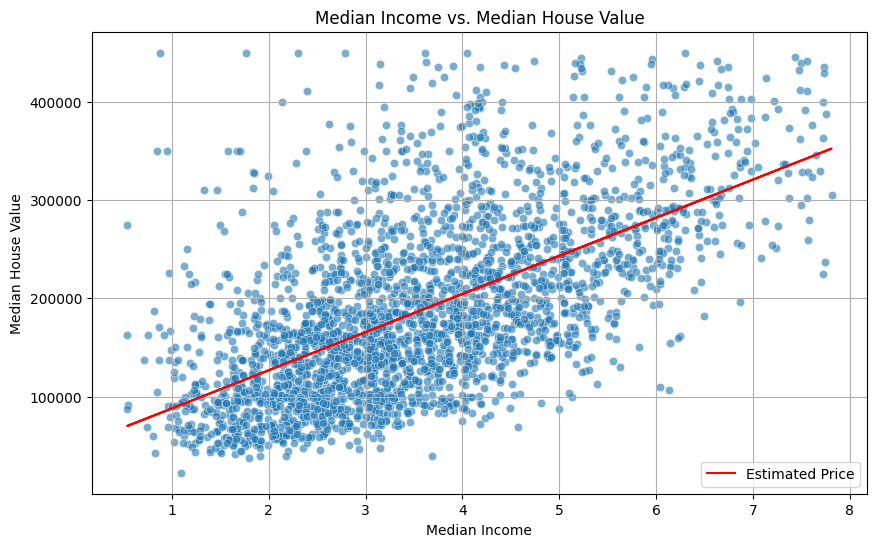

In [32]:
try_parameters(model.coef_,model.intercept_)

MULTIPLE LINEAR REGRESSION


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

### 1. Define Features (X) and Target (y)

In [34]:
x = df[['median_income', 'total_rooms', 'housing_median_age']]
y = df['median_house_value']

### 3. Train the Multiple Linear Regression Model

In [35]:
multi_model = LinearRegression()
multi_model.fit(x, y)

LinearRegression()

### 4. Make Predictions

In [36]:
y_pred = multi_model.predict(x)

### 5. Evaluate the Model

In [37]:
rmse_multi = np.sqrt(mean_squared_error(y, y_pred))
r2_multi = r2_score(y, y_pred)

print(f'Multiple Linear Regression RMSE: {rmse_multi}')
print(f'Multiple Linear Regression R-squared: {r2_multi*100} %')

Multiple Linear Regression RMSE: 68252.95299239892
Multiple Linear Regression R-squared: 42.489864673065426 %


In [38]:
model.intercept_

array([49225.60079947])

In [39]:
multi_model.intercept_

np.float64(-16301.89630913714)

In [40]:
model.coef_

array([[38805.09029436]])

In [41]:
multi_model.coef_

array([4.06190792e+04, 3.75905549e+00, 1.72491581e+03])

### Visualizing Multiple Linear Regression Predictions

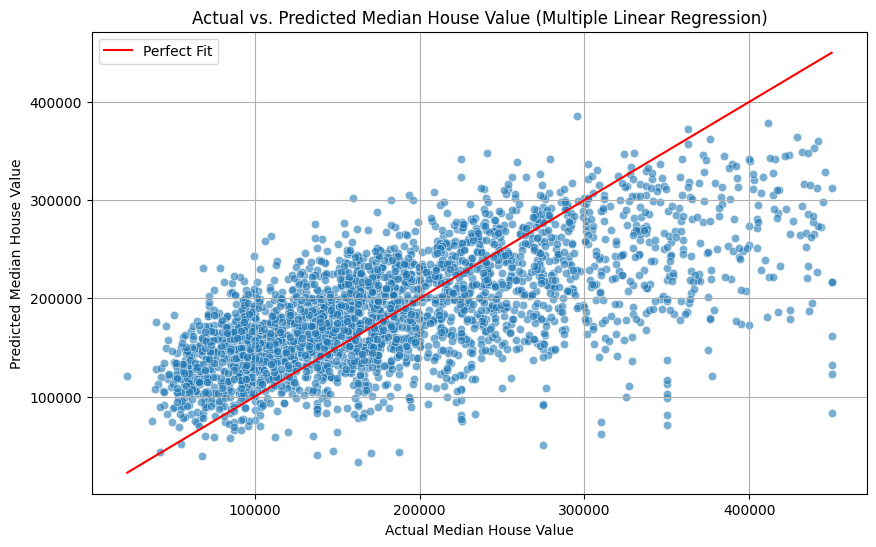

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', label='Perfect Fit')
plt.title('Actual vs. Predicted Median House Value (Multiple Linear Regression)')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.grid(True)
plt.legend()
plt.show()

POLYNOMIAL REGRESSION


In [43]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

### 1. Define Features (X) and Target (y) for Polynomial Regression

In [44]:
# For polynomial regression, we can select features to transform.
# Let's use 'median_income' and 'total_rooms' for demonstration. You can add more if needed.
X_poly = df[['median_income', 'total_rooms']]
y_poly = df['median_house_value']

### 2. Create Polynomial Features

In [45]:
# Create polynomial features with degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_transformed = poly.fit_transform(X_poly)

### 3. Train a Linear Regression Model on Polynomial Features

In [46]:
poly_model = LinearRegression()
poly_model.fit(X_poly_transformed, y_poly)

LinearRegression()

### 4. Make Predictions

In [47]:
y_poly_pred = poly_model.predict(X_poly_transformed)

### 5. Evaluate the Polynomial Regression Model

In [48]:
rmse_poly = np.sqrt(mean_squared_error(y_poly, y_poly_pred))
r2_poly = r2_score(y_poly, y_poly_pred)

print(f'Polynomial Regression RMSE: {rmse_poly}')
print(f'Polynomial Regression R-squared: {r2_poly*100} %')

Polynomial Regression RMSE: 70837.76720687709
Polynomial Regression R-squared: 38.05143864103832 %


### Testing Models on Original Test Data

In [49]:
test_data_raw = pd.read_csv('/content/sample_data/california_housing_test.csv')
display(test_data_raw.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


#### Multiple Linear Regression Model Evaluation on Test Data

In [50]:
# Define features (X_test) and target (y_test) for Multiple Linear Regression
X_test_multi = test_data_raw[['median_income', 'total_rooms', 'housing_median_age']]
y_test_multi = test_data_raw['median_house_value']

# Make predictions on the test data
y_pred_multi_test = multi_model.predict(X_test_multi)

# Evaluate the model
rmse_multi_test = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi_test))
r2_multi_test = r2_score(y_test_multi, y_pred_multi_test)

print(f'Multiple Linear Regression RMSE on Test Data: {rmse_multi_test}')
print(f'Multiple Linear Regression R-squared on Test Data: {r2_multi_test*100} %')

Multiple Linear Regression RMSE on Test Data: 80811.07450643109
Multiple Linear Regression R-squared on Test Data: 48.94830585982357 %


#### Polynomial Regression Model Evaluation on Test Data

In [51]:
# Define features (X_test) and target (y_test) for Polynomial Regression
X_test_poly = test_data_raw[['median_income', 'total_rooms']]
y_test_poly = test_data_raw['median_house_value']

# Transform the test features using the already fitted PolynomialFeatures object
X_test_poly_transformed = poly.transform(X_test_poly)

# Make predictions on the transformed test data
y_pred_poly_test = poly_model.predict(X_test_poly_transformed)

# Evaluate the model
rmse_poly_test = np.sqrt(mean_squared_error(y_test_poly, y_pred_poly_test))
r2_poly_test = r2_score(y_test_poly, y_pred_poly_test)

print(f'Polynomial Regression RMSE on Test Data: {rmse_poly_test}')
print(f'Polynomial Regression R-squared on Test Data: {r2_poly_test*100} %')

Polynomial Regression RMSE on Test Data: 85517.53602487606
Polynomial Regression R-squared on Test Data: 42.82860959697854 %


DICISION TREE

### Decision Tree Regressor Model Evaluation on Test Data

In [52]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2994,-117.93,33.86,35.0,931.0,181.0,516.0,174.0,5.5867,182500.0
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0


In [53]:
x=df.iloc[:, 1:-1].values

In [54]:
y=df.iloc[:, -1].values

In [55]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 0)
regressor.fit(x, y)

DecisionTreeRegressor(random_state=0)

In [56]:
X_test_dt = test_data_raw.iloc[:, 1:-1].values
y_test_dt = test_data_raw.iloc[:, -1].values

y_pred_dt_test = regressor.predict(X_test_dt)

rmse_dt_test = np.sqrt(mean_squared_error(y_test_dt, y_pred_dt_test))
r2_dt_test = r2_score(y_test_dt, y_pred_dt_test)

print(f'Decision Tree Regressor RMSE on Test Data: {rmse_dt_test}')
print(f'Decision Tree Regressor R-squared on Test Data: {r2_dt_test*100} %')

Decision Tree Regressor RMSE on Test Data: 49969.5647900633
Decision Tree Regressor R-squared on Test Data: 80.4800127456612 %


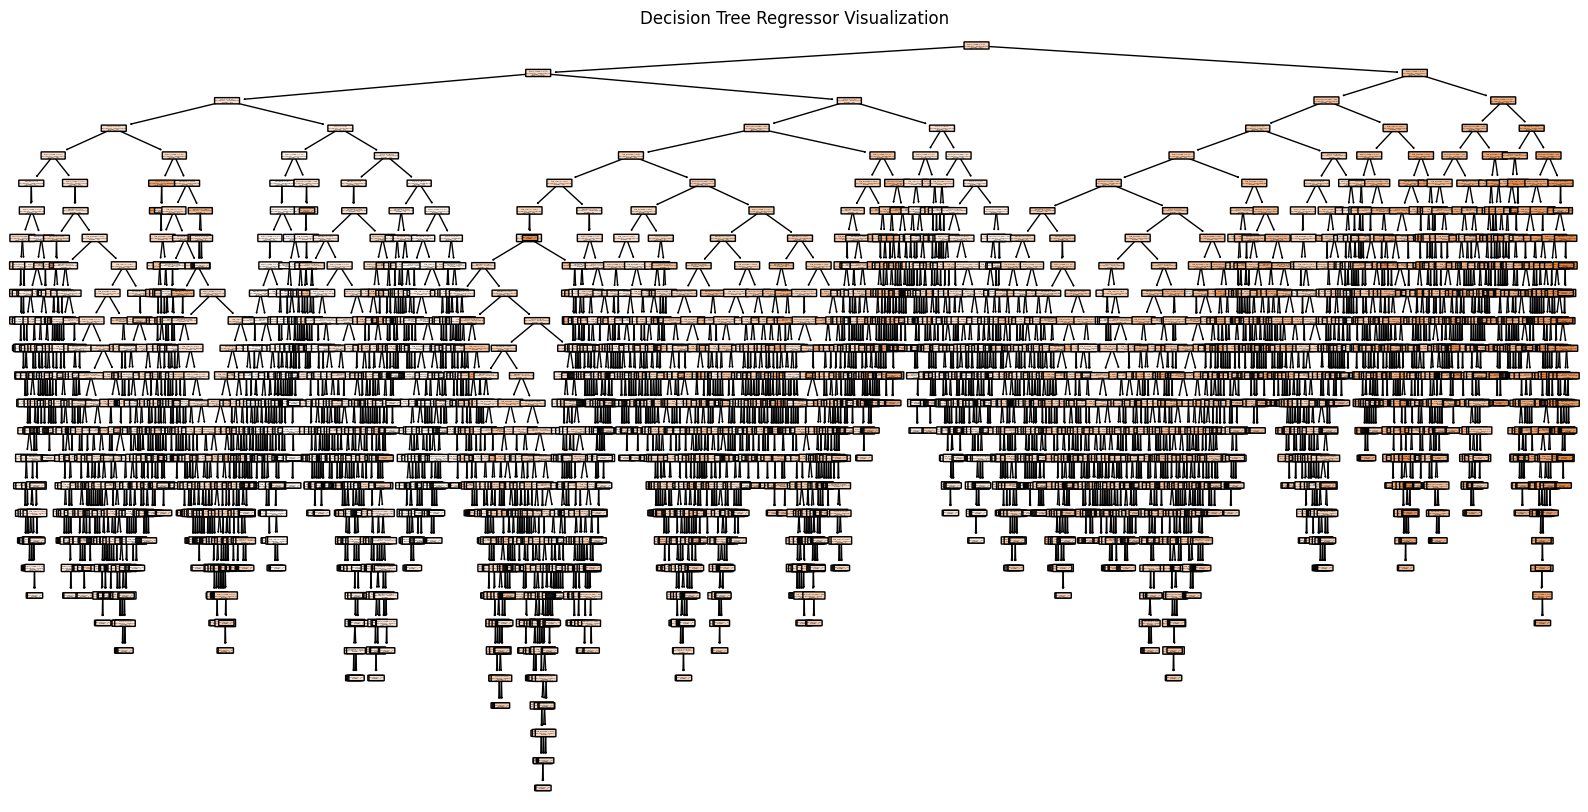

In [57]:
plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
from sklearn import tree
tree.plot_tree(regressor, filled=True, feature_names=test_data_raw.iloc[:, 1:-1].columns.tolist(), rounded=True)
plt.title('Decision Tree Regressor Visualization')
plt.show()

RANDOM FOREST

In [58]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(x, y)

RandomForestRegressor(n_estimators=10, random_state=0)

In [59]:
X_test_dt = test_data_raw.iloc[:, 1:-1].values
y_test_dt = test_data_raw.iloc[:, -1].values

y_pred_dt_test = regressor.predict(X_test_dt)

rmse_dt_test = np.sqrt(mean_squared_error(y_test_dt, y_pred_dt_test))
r2_dt_test = r2_score(y_test_dt, y_pred_dt_test)

print(f'Random Forest Regressor RMSE on Test Data: {rmse_dt_test}')
print(f'Random Forest Regressor R-squared on Test Data: {r2_dt_test*100} %')

Random Forest Regressor RMSE on Test Data: 51003.19964350276
Random Forest Regressor R-squared on Test Data: 79.6641073834637 %


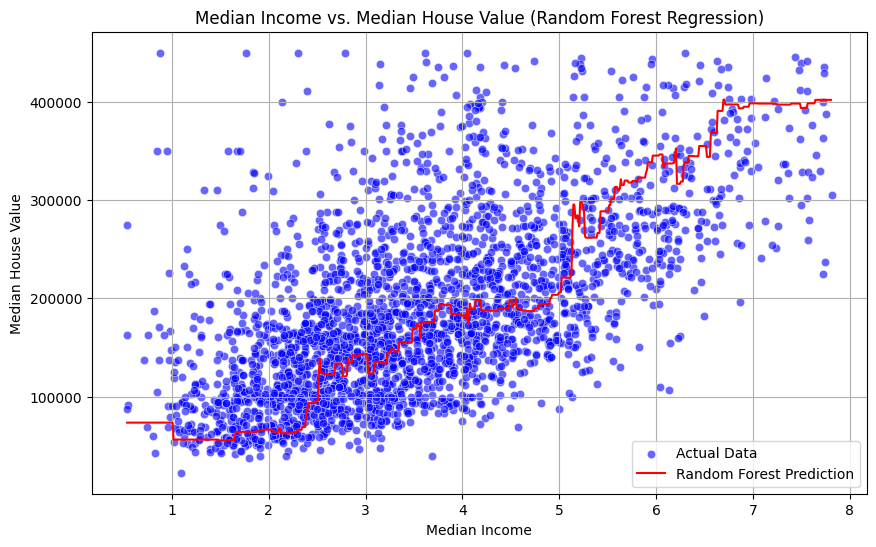

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['median_income'], y=df['median_house_value'], color='blue', alpha=0.6, label='Actual Data')
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
feature_names = ['latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
median_income_idx = feature_names.index('median_income')

X_grid_income = np.arange(x[:, median_income_idx].min(), x[:, median_income_idx].max(), 0.01).reshape(-1, 1)

mean_features = np.mean(x, axis=0)

# Replicate the mean_features for each point in X_grid_income
X_grid_full = np.tile(mean_features, (len(X_grid_income), 1))

# Replace the 'median_income' column in X_grid_full with X_grid_income
X_grid_full[:, median_income_idx] = X_grid_income.flatten()

# Predict using the Random Forest Regressor
y_pred_rf_grid = regressor.predict(X_grid_full)

plt.plot(X_grid_income, y_pred_rf_grid, color='red', label='Random Forest Prediction')
plt.title('Median Income vs. Median House Value (Random Forest Regression)')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True)
plt.show()